In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/sales2.xlsx - Sheet1.csv")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/09 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/09 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/09 7:45,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420311 entries, 0 to 420310
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      420311 non-null  object 
 1   StockCode    420311 non-null  object 
 2   Description  417803 non-null  object 
 3   Quantity     420311 non-null  int64  
 4   InvoiceDate  420311 non-null  object 
 5   Price        420311 non-null  float64
 6   Customer ID  337233 non-null  float64
 7   Country      420311 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 25.7+ MB


In [5]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
420306,529593,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,10/29/10 8:23,0.55,12921.0,United Kingdom
420307,529593,84692,BOX OF 24 COCKTAIL PARASOLS,25,10/29/10 8:23,0.42,12921.0,United Kingdom
420308,529593,21042,RED RETROSPOT APRON,3,10/29/10 8:23,5.95,12921.0,United Kingdom
420309,529593,21154,RED RETROSPOT OVEN GLOVE,10,10/29/10 8:23,1.25,12921.0,United Kingdom
420310,529593,84997B,RED 3 PIECE RETROSPOT CUTLERY SET,6,10/29/10 8:23,3.75,12921.0,United Kingdo


In [6]:
df.isnull()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
420306,False,False,False,False,False,False,False,False
420307,False,False,False,False,False,False,False,False
420308,False,False,False,False,False,False,False,False
420309,False,False,False,False,False,False,False,False


In [7]:
df.describe()

,Quantity,Price,Customer ID
count,420311.000000,420311.000000,337233.000000
mean,10.826419,4.713889,15331.596178
std,114.005885,156.527903,1674.809802
min,-9600.000000,-53594.360000,12346.000000
25%,1.000000,1.250000,13968.000000
50%,3.000000,2.100000,15271.000000
75%,12.000000,4.210000,16782.000000
max,19152.000000,25111.090000,18287.000000


In [8]:
df.shape

(420311, 8)

In [9]:
df=df.dropna(subset=["Customer ID"])

In [10]:
# Remove cancelled invoices
df=df[~df["InvoiceDate"].astype(str).str.startswith("C")]

In [11]:
# Remove invalid transactions
df=df[(df["Quantity"]>0)&(df["Price"]>0)]

In [12]:
#Remove duplicates

In [13]:
df=df.drop_duplicates()

In [14]:
df["TotalAmount"]=df["Quantity"]*df["Price"]

In [15]:
print(df["TotalAmount"].head())

0     83.4
1     81.0
2     81.0
3    100.8
4     30.0
Name: TotalAmount, dtype: float64


In [18]:

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
reference_date=df["InvoiceDate"].max()+pd.Timedelta(days=1)
rfm=df.groupby("Customer ID").agg(
    Recency=("InvoiceDate",
             lambda x:(reference_date-x.max()).days),
    Frequency=("Invoice","nunique"),
    Monetary=("TotalAmount","sum")
)
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
12346.0          123         11    372.86
12348.0           32          1    222.16
12349.0            2          3   2671.14
12353.0            2          1    317.76
12355.0          161          1    488.21


In [19]:
from sklearn.preprocessing import StandardScaler

features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[features])

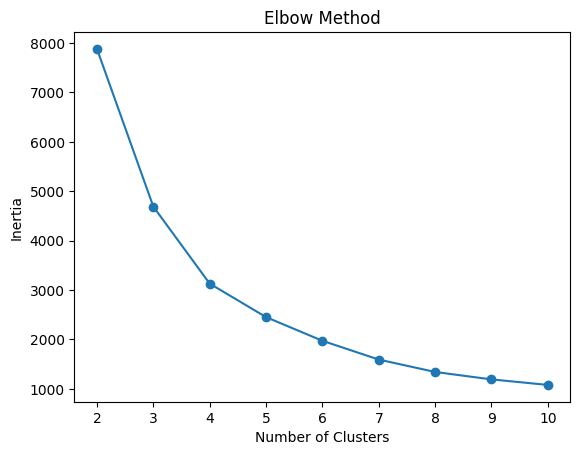

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [21]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [22]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.9220486495367629


In [23]:
from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Davies-Bouldin Index:", db_index)

Davies-Bouldin Index: 0.6259898660817513


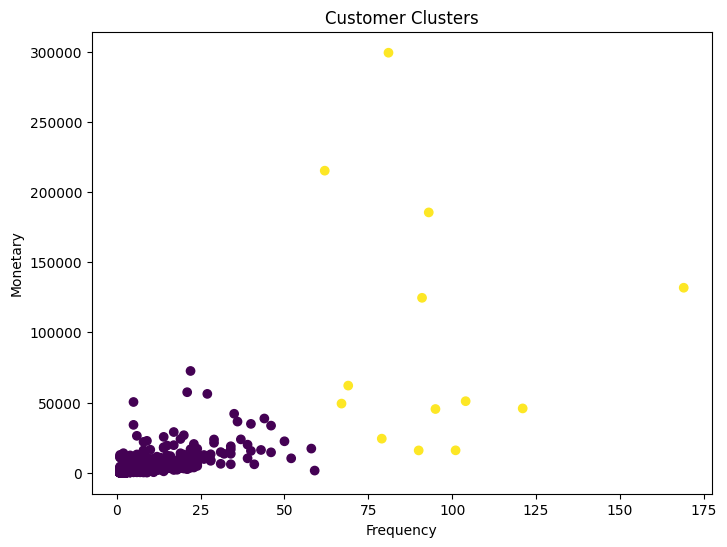

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Clusters")
plt.show()

In [25]:
cluster_summary = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

print(cluster_summary)

           Recency  Frequency      Monetary
Cluster                                    
0        89.667519   3.702813   1531.957706
1        10.538462  94.000000  97381.952308
